<div style="font-size:18px;font-weight:700">UBUZIMA AI — clone your own voice</div><div style="font-size:13px;line-height:1.45;color:#333;margin-top:4px">Give <code>DigitalUmuganda/Kinyarwanda_YourTTS_v1</code> ~1 minute of your voice and it speaks Kinyarwanda in your voice. You do not train anything — a speaker encoder turns your recording into a d-vector and the synthesiser conditions on it.<br><br><b>Runtime → CPU is fine.</b> No GPU needed. At the end you download <code>reference.wav</code> and commit it to your Space.<br><br><span style="color:#888">One honest expectation: this clones your <i>timbre</i>, not Kinyarwanda <i>tone</i>. The model is grapheme-based (<code>use_phonemes: False</code>) so tonal contours can't be recovered — that's a §5.4 finding, not a bug in your recording.</span></div>

<div style="font-size:13px;line-height:1.45"><div style="font-size:15px;font-weight:600;margin:2px 0 4px"><span style="background:#2E74B5;color:#fff;border-radius:4px;padding:1px 7px;font-size:12px;margin-right:8px">1</span>Install</div>~3–5 min. <code>coqui-tts</code> is the maintained fork of the archived <code>TTS</code> package and keeps the <code>TTS</code> import path.</div>

In [3]:
# Install everything, pinning transformers to the ONE version that works with
# both coqui-tts and your ASR model. The trap that bit the earlier runs:
#   - Colab ships transformers 5.x; coqui-tts needs isin_mps_friendly (removed in 5.x)
#   - `pip install TTS` (capital) is the ARCHIVED package — it won't install on 3.12
# The package you want is `coqui-tts` (lowercase), which provides the `TTS` import.
!pip install -q coqui-tts==0.25.3 "transformers==4.46.2" "numpy<2.0" librosa soundfile 2>&1 | tail -20

import importlib
ok = importlib.util.find_spec("TTS") is not None
try:
    from transformers.pytorch_utils import isin_mps_friendly
    canary = True
except Exception:
    canary = False
print("\nTTS installed:", ok, "| transformers compatible:", canary)
if ok and canary:
    print("✅ Good. Now run the RESTART cell below ONCE, then skip both installs.")
else:
    print("⚠ Read the pip output above and send it back.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.0/865.0 kB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.8/50.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 111.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.1/65.1 kB 6.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 5.0.0.93 req

In [ ]:
# ── RESTART — run ONCE after the install cell. Looks like a crash; that IS the
# restart. Afterwards SKIP both install cells and run from the SCRIPT cell down.
import os
os.kill(os.getpid(), 9)

<div style="font-size:13px;line-height:1.45"><div style="font-size:15px;font-weight:600;margin:2px 0 4px"><span style="background:#2E74B5;color:#fff;border-radius:4px;padding:1px 7px;font-size:12px;margin-right:8px">2</span>Your 90-second script</div>Read this straight through, <b>calmly, like you're explaining to a patient</b> — not like a news anchor, not slowly. The clone copies your delivery. It's built to make the encoder hear your full range: statements, questions, the real disclaimer and refusal, numbers, the emergency line. Flat input → flat clone.<br><span style='color:#888'>You're the native speaker — if a phrase isn't how a health worker would say it, change it. Natural-you beats faithful-to-the-text.</span></div>

In [1]:
SCRIPT = """
Muraho neza. Nditwa UBUZIMA AI, ndi umufasha wawe mu byerekeye ubuzima. Nshobora
kugufasha kubona amakuru y'ubuzima mu rurimi rwawe, ariko ndagira ngo ubanze umenye
ikintu kimwe cy'ingenzi.

Nifuzaga ko wamenya ko ntabwo ndi muganga. Amakuru ntanga ni ay'ubumenyi rusange gusa.
Ese wari ubizi ko hari indwara nyinshi zishobora kwirindwa mu buryo bworoshye?

Reka tuvuge kuri malariya. Malariya iterwa n'umubu, kandi ikwirakwira cyane mu gihe
cy'imvura. Ni gute wakwirinda? Icya mbere, ryama mu nzitiramubu buri joro. Icya kabiri,
kuraho amazi ahagaze hafi y'inzu yawe. Icya gatatu, niba ufite umuriro, jya kwipimisha vuba.

Umubyeyi utwite akeneye kwitondera ubuzima bwe. Agomba kurya indyo yuzuye, akanywa amazi
ahagije, kandi akajya mu isuzuma nibura inshuro enye mu gihe atwite.

Icyitonderwa cy'ingenzi: aya makuru ni ay'ubumenyi rusange, si isuzuma rya muganga.
Nyamuneka, sura umuganga cyangwa ujye ku kigo nderabuzima kikwegereye kugira ngo ubone
ubufasha bwihariye kuri wowe.

Kandi niba ari ibintu byihutirwa cyane, ntutegereze. Hamagara nomero 912, cyangwa ujye
ku bitaro biri hafi yawe ako kanya. Ubuzima bwawe ni ingenzi. Murakoze kunyumva.
"""
from IPython.display import HTML, display
w = len(SCRIPT.split())
display(HTML(f'<div style="font-size:15px;line-height:1.7;background:#f7f9fc;border-left:4px '
             f'solid #2E74B5;padding:14px 18px;border-radius:4px;white-space:pre-wrap">'
             f'{SCRIPT.strip()}</div>'
             f'<div style="font-size:12px;color:#888;margin-top:6px">{w} words ≈ '
             f'{w/2.5:.0f}s at a natural pace. If short, read it twice.</div>'))

<div style="font-size:13px;line-height:1.45"><div style="font-size:15px;font-weight:600;margin:2px 0 4px"><span style="background:#2E74B5;color:#fff;border-radius:4px;padding:1px 7px;font-size:12px;margin-right:8px">3</span>Record here</div>Allow microphone access, read the script above, click STOP when done. Or skip to the upload cell if you recorded on your phone.</div>

In [ ]:
from IPython.display import Javascript, display
from google.colab import output
from base64 import b64decode

RECORD_JS = """
var record = async () => {
  const div = document.createElement('div');
  const btn = document.createElement('button');
  btn.textContent = '⏹  STOP RECORDING';
  btn.style.cssText='font-size:18px;padding:12px 24px;background:#c00;color:#fff;border:none;border-radius:6px;cursor:pointer';
  div.appendChild(btn);
  const timer=document.createElement('span');
  timer.style.cssText='font-size:18px;margin-left:16px;font-family:monospace';
  div.appendChild(timer); document.body.appendChild(div);
  const stream=await navigator.mediaDevices.getUserMedia({audio:{channelCount:1,
      echoCancellation:false,noiseSuppression:false,autoGainControl:false}});
  const rec=new MediaRecorder(stream); const chunks=[];
  rec.ondataavailable=e=>chunks.push(e.data); rec.start(); const t0=Date.now();
  const iv=setInterval(()=>{const s=Math.floor((Date.now()-t0)/1000);
    timer.textContent=`${String(Math.floor(s/60)).padStart(2,'0')}:${String(s%60).padStart(2,'0')}`
      +(s>=90?'  ✓ enough':'  (aim 90s)');},250);
  await new Promise(r=>btn.onclick=r); clearInterval(iv); rec.stop();
  await new Promise(r=>rec.onstop=r); stream.getTracks().forEach(t=>t.stop()); div.remove();
  const blob=new Blob(chunks);
  return await new Promise(r=>{const fr=new FileReader();fr.onloadend=()=>r(fr.result);fr.readAsDataURL(blob);});
};"""
display(Javascript(RECORD_JS))
raw = b64decode(output.eval_js('record()').split(',')[1])
open('raw_voice.webm','wb').write(raw)
RAW='raw_voice.webm'; print(f"saved {RAW} ({len(raw)/1e6:.2f} MB)")

<div style="font-size:13px;line-height:1.45"><div style="font-size:15px;font-weight:600;margin:2px 0 4px"><span style="background:#2E74B5;color:#fff;border-radius:4px;padding:1px 7px;font-size:12px;margin-right:8px">3b</span>...or upload instead</div>Skip this if you used the recorder above.</div>

In [2]:
from google.colab import files

RAW = list(files.upload().keys())[0]
print("using", RAW)

Saving WhatsApp Ptt 2026-07-18 at 13.13.44.webm to WhatsApp Ptt 2026-07-18 at 13.13.44.webm
using WhatsApp Ptt 2026-07-18 at 13.13.44.webm


<div style="font-size:13px;line-height:1.45"><div style="font-size:15px;font-weight:600;margin:2px 0 4px"><span style="background:#2E74B5;color:#fff;border-radius:4px;padding:1px 7px;font-size:12px;margin-right:8px">4</span>Check it before you trust it</div>Duration, level, clipping, SNR, waveform. Fix any <b>❌</b> and re-record — ten minutes now saves a bad demo later.</div>

/tmp/ipykernel_4050/131572052.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(RAW, sr=None, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


duration   133.2s   ✅ enough
level      -18.3dB  ✅ good
peak        1.00    ❌ CLIPPING — back off mic
clipped     0.03%   ✅ clean
est SNR     82.9dB  ✅ quiet room


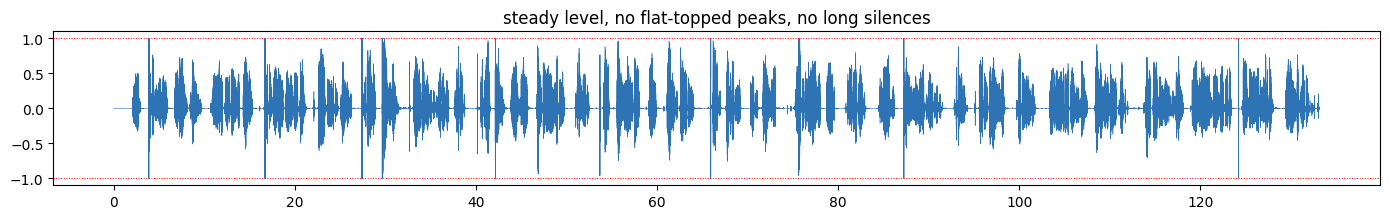

In [3]:
import librosa, numpy as np, matplotlib.pyplot as plt
y, sr = librosa.load(RAW, sr=None, mono=True)
peak=float(np.abs(y).max())
if peak < 1e-4:
    raise SystemExit(
        "\n❌ THIS RECORDING IS SILENT (peak = %.6f).\n"
        "The microphone captured nothing — most likely the mic permission was\n"
        "dismissed, or Colab could not reach your mic. Two fixes:\n"
        "  1. Re-run the record cell and click ALLOW on the permission popup, OR\n"
        "  2. Record on your phone, then use the UPLOAD cell instead of the recorder.\n"
        "Then re-run this check." % peak)
dur=len(y)/sr; rms=float(np.sqrt(np.mean(y**2))); rms_db=20*np.log10(rms+1e-9)
clip=100*float(np.mean(np.abs(y)>=0.99))
fr=librosa.feature.rms(y=y)[0]; s=np.sort(fr)
snr=20*np.log10((s[-len(s)//10:].mean()+1e-9)/(s[:len(s)//10].mean()+1e-9))
ok=lambda c,g,b: f"✅ {g}" if c else f"❌ {b}"
print(f"duration  {dur:6.1f}s   {ok(dur>=60,'enough','record more, aim 90s')}")
print(f"level     {rms_db:6.1f}dB  {ok(-32<rms_db<-14,'good','too quiet/hot')}")
print(f"peak      {peak:6.2f}    {ok(peak<0.99,'no clipping','CLIPPING — back off mic')}")
print(f"clipped   {clip:6.2f}%   {ok(clip<0.1,'clean','redo')}")
print(f"est SNR   {snr:6.1f}dB  {ok(snr>20,'quiet room','too noisy')}")
plt.figure(figsize=(14,2.3)); plt.plot(np.linspace(0,dur,len(y)),y,lw=.4,color='#2E74B5')
plt.axhline(1,color='r',ls=':',lw=.7); plt.axhline(-1,color='r',ls=':',lw=.7)
plt.title('steady level, no flat-topped peaks, no long silences'); plt.tight_layout(); plt.show()

<div style="font-size:13px;line-height:1.45"><div style="font-size:15px;font-weight:600;margin:2px 0 4px"><span style="background:#2E74B5;color:#fff;border-radius:4px;padding:1px 7px;font-size:12px;margin-right:8px">5</span>Prepare the reference</div>16 kHz mono, trim silence, normalise to −23 dBFS, cap 60 s, plus 3 chunks for d-vector averaging.</div>

In [4]:
import soundfile as sf
from pathlib import Path
SR=16000; OUT=Path('voices/ganza'); OUT.mkdir(parents=True,exist_ok=True)
x=librosa.load(RAW,sr=SR,mono=True)[0]
iv=librosa.effects.split(x,top_db=30); gap=np.zeros(int(0.15*SR),dtype='float32')
x=np.concatenate([np.concatenate([x[s:e],gap]) for s,e in iv]) if len(iv) else x
if len(x)/SR<20: raise SystemExit("Under 20s of speech — record more.")
if len(x)/SR>60: x=x[:60*SR]
x=x*(10**(-23/20)/(np.sqrt(np.mean(x**2))+1e-9))
if np.abs(x).max()>0.97: x=x/np.abs(x).max()*0.97
sf.write(OUT/'reference.wav',x,SR)
step=len(x)//3
for i in range(3): sf.write(OUT/f'chunk_{i+1}.wav',x[i*step:(i+1)*step],SR)
REFERENCE=str(OUT/'reference.wav')
print(f"✅ {REFERENCE}  {len(x)/SR:.1f}s @ {SR}Hz, {20*np.log10(np.sqrt(np.mean(x**2))):.1f} dBFS")

/tmp/ipykernel_4050/2195420223.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  x=librosa.load(RAW,sr=SR,mono=True)[0]
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


✅ voices/ganza/reference.wav  60.0s @ 16000Hz, -23.0 dBFS


<div style="font-size:13px;line-height:1.45"><div style="font-size:15px;font-weight:600;margin:2px 0 4px"><span style="background:#2E74B5;color:#fff;border-radius:4px;padding:1px 7px;font-size:12px;margin-right:8px">6</span>Fetch the model</div>Lists what's actually in the repo and picks by pattern — I couldn't browse it, so this doesn't trust hard-coded filenames.</div>

In [5]:
from huggingface_hub import snapshot_download
REPO="DigitalUmuganda/KinyarwandaTTS_female_voice"; local=Path(snapshot_download(REPO))
for f in sorted(local.rglob('*')):
    if f.is_file(): print(f"  {f.relative_to(local)!s:<42}{f.stat().st_size/1e6:8.2f} MB")
def find(*ps):
    for p in ps:
        h=sorted(local.rglob(p))
        if h: return str(h[0])
    return None
CKPT=find('best_model.pth','model.pth','*.pth'); CONFIG=find('config.json')
SPEAKERS=find('speakers.pth','speakers.json'); SE_CKPT=find('SE_checkpoint.pth.tar','*SE*.pth*')
SE_CONFIG=find('config_se.json','*se*.json'); DEFAULT=find('conditioning_audio.wav','*.wav')
print("\npicked:", {k:(Path(v).name if v else None) for k,v in
      dict(ckpt=CKPT,config=CONFIG,speakers=SPEAKERS,se=SE_CKPT,default=DEFAULT).items()})
if not CKPT or not CONFIG: raise SystemExit("No checkpoint/config — set CKPT/CONFIG by hand from the listing.")
if not SE_CKPT: print("\n⚠ No speaker encoder found — zero-shot cloning may fall back to built-in speakers.")

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

config.json: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

conditioning_audio.wav:   0%|          | 0.00/1.25M [00:00<?, ?B/s]

model.pth:   0%|          | 0.00/1.04G [00:00<?, ?B/s]

...

conditioning_audio2.wav:   0%|          | 0.00/518k [00:00<?, ?B/s]

speakers.pth:   0%|          | 0.00/55.1M [00:00<?, ?B/s]

config_se.json: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

  .gitattributes                                0.00 MB
  README.md                                     0.00 MB
  SE_checkpoint.pth.tar                        44.61 MB
  conditioning_audio.wav                        1.25 MB
  conditioning_audio2.wav                       0.52 MB
  config.json                                   0.01 MB
  config_se.json                                0.00 MB
  model.pth                                  1039.97 MB
  speakers.pth                                 55.09 MB

picked: {'ckpt': 'model.pth', 'config': 'config.json', 'speakers': 'speakers.pth', 'se': 'SE_checkpoint.pth.tar', 'default': 'conditioning_audio.wav'}


In [6]:
import json, glob
cands = glob.glob(str(local/"**"/"speakers*.pth"), recursive=True) + \
        glob.glob(str(local/"**"/"speakers*.json"), recursive=True)
real = cands[0] if cands else None
print("speakers file:", real or "none — encoder will compute live")

cfg = json.load(open(CONFIG))
def fix(d):
    for k,v in list(d.items()):
        if isinstance(v, dict): fix(v)
        elif isinstance(v, str) and ("/workspace/" in v or "segmented_24k" in v):
            d[k] = real if (k in ("d_vector_file","speakers_file") and real) else None
            print(f"  fixed {k}")
fix(cfg)
if not real:
    cfg.setdefault("model_args", cfg)["use_d_vector_file"] = False
CONFIG = "/content/config_patched.json"
json.dump(cfg, open(CONFIG,"w"))
print("✅ patched — re-run the synthesiser cell now")

speakers file: /root/.cache/huggingface/hub/models--DigitalUmuganda--KinyarwandaTTS_female_voice/snapshots/b02032eaccec592e9ab5bd1843a31213faad3d31/speakers.pth
✅ patched — re-run the synthesiser cell now


<div style="font-size:13px;line-height:1.45"><div style="font-size:15px;font-weight:600;margin:2px 0 4px"><span style="background:#2E74B5;color:#fff;border-radius:4px;padding:1px 7px;font-size:12px;margin-right:8px">7</span>Load the synthesiser</div></div>

In [7]:
# ── Load the model DIRECTLY, bypassing Synthesizer and its broken speakers.pth ──
import torch, json, glob
from TTS.tts.configs.vits_config import VitsConfig
from TTS.tts.models.vits import Vits
from TTS.utils.audio import AudioProcessor

cfg = VitsConfig()
cfg.load_json(glob.glob(str(local / "**" / "config.json"), recursive=True)[0])
for holder in (cfg, getattr(cfg, "model_args", None)):
    if holder is None: continue
    for attr in ("d_vector_file", "speakers_file", "speaker_ids_file"):
        if hasattr(holder, attr): setattr(holder, attr, None)

ap = AudioProcessor.init_from_config(cfg)
model = Vits.init_from_config(cfg)
model.load_checkpoint(cfg, CKPT, eval=True)

if SE_CKPT and SE_CONFIG:
    model.speaker_manager.init_encoder(SE_CKPT, SE_CONFIG)
    print("speaker encoder loaded — cloning enabled")
else:
    print("⚠ no speaker encoder found; default voice")

model.eval()
TTS_SR = cfg.audio["sample_rate"]
print(f"✅ loaded · {TTS_SR} Hz · use_phonemes={cfg.use_phonemes}")

/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")


speaker encoder loaded — cloning enabled
✅ loaded · 16000 Hz · use_phonemes=False


In [24]:
# ── Synthesise in your cloned voice — exact path from the TTS source ──
import numpy as np, soundfile as sf, torch
from pathlib import Path
from IPython.display import Audio, display, HTML
from TTS.tts.utils.synthesis import synthesis

# turn your reference.wav into a speaker embedding, once
d_vector = model.speaker_manager.compute_embedding_from_clip(REFERENCE)
print("d-vector computed from your reference ✓")

def say(text, out=None):
    outputs = synthesis(
        model=model, text=text, CONFIG=cfg,
        use_cuda=torch.cuda.is_available(),
        d_vector=d_vector, use_griffin_lim=True,
    )
    wav = np.asarray(outputs["wav"], dtype=np.float32).squeeze()
    if out: sf.write(out, wav, TTS_SR)
    return wav

SENTENCES=["Muraho. Ndi UBUZIMA AI, umufasha w'amakuru y'ubuzima.",
 "Malariya iterwa n'umubu witwa anofele. Kwirinda ni ukuryama mu nzitiramubu.",
 "Umubyeyi utwite agomba kurya indyo yuzuye, akanywa amazi ahagije, kandi akajya kwipimisha buri kwezi.",
 "Icyitonderwa: aya ni amakuru rusange y'ubuzima, si isuzuma rya muganga. Nyamuneka sura umuganga cyangwa ujye ku kigo nderabuzima kikwegereye.",
 "Simbasha kukubwira indwara ufite. Nyamuneka jya ku kigo nderabuzima kikwegereye vuba bishoboka."]
LABELS=["greeting","health answer","health answer (long)","⭐ DISCLAIMER","⭐ REFUSAL"]

Path('voice_auditions').mkdir(exist_ok=True)
for i,(t,l) in enumerate(zip(SENTENCES,LABELS),1):
    p=f'voice_auditions/ganza_{i}.wav'
    try:
        say(t, out=p)
        display(HTML(f"<b style='font-size:13px'>{l}</b><br><span style='font-size:12px;color:#555'>{t}</span>"))
        display(Audio(p))
    except Exception as e:
        import traceback; print(f"sentence {i} failed: {e}"); traceback.print_exc()

d-vector computed from your reference ✓


<div style="font-size:13px;line-height:1.45"><div style="font-size:15px;font-weight:600;margin:2px 0 4px"><span style="background:#2E74B5;color:#fff;border-radius:4px;padding:1px 7px;font-size:12px;margin-right:8px">8</span>Audition — your voice, real sentences</div>These are what your system actually says. <b>Sentences 4 and 5 (disclaimer, refusal) matter most</b> — judge on those.</div>

In [23]:
# ── DIAGNOSTIC: is your voice actually being used? ──
import numpy as np, torch, glob

sm = model.speaker_manager
print("1. speaker_manager exists      :", sm is not None)
print("   has encoder                 :", getattr(sm, "encoder", None) is not None)
print("   has encoder_ap              :", getattr(sm, "encoder_ap", None) is not None)

default_wav = glob.glob(str(local / "**" / "conditioning_audio.wav"), recursive=True)
mine = np.asarray(sm.compute_embedding_from_clip(REFERENCE)).squeeze()
print("\n2. your d-vector first 3        :", np.round(mine[:3],4))
if default_wav:
    theirs = np.asarray(sm.compute_embedding_from_clip(default_wav[0])).squeeze()
    cos = float(np.dot(mine, theirs)/(np.linalg.norm(mine)*np.linalg.norm(theirs)+1e-9))
    print("   default d-vector first 3    :", np.round(theirs[:3],4))
    print("   cosine mine↔default         :", round(cos,4),
          "\n   -> ~1.0 means your file ISN'T being read; <0.9 means they differ (good)")

print("\n3. embedded_speaker_dim        :", getattr(model,"embedded_speaker_dim","?"),
      "| use_d_vector_file:", model.args.use_d_vector_file,
      "\n   -> must be > 0 or external voices are ignored")

1. speaker_manager exists      : True
   has encoder                 : True
   has encoder_ap              : True

2. your d-vector first 3        : [0.0142 0.0164 0.0361]
   default d-vector first 3    : [ 0.0159 -0.0467 -0.0458]
   cosine mine↔default         : 0.4822 
   -> ~1.0 means your file ISN'T being read; <0.9 means they differ (good)

3. embedded_speaker_dim        : 512 | use_d_vector_file: True 
   -> must be > 0 or external voices are ignored


In [18]:
# ── PROVE it: your voice vs default, same sentence ──
import numpy as np, soundfile as sf, torch, glob
from TTS.tts.utils.synthesis import synthesis
from IPython.display import Audio, display, HTML

sm = model.speaker_manager
TEXT = "Muraho, ndi UBUZIMA AI, umufasha wawe mu byerekeye ubuzima."

def gen(dvec):
    out = synthesis(model=model, text=TEXT, CONFIG=cfg,
                    use_cuda=torch.cuda.is_available(),
                    d_vector=dvec, use_griffin_lim=True)["wav"]
    return np.asarray(out, dtype=np.float32).squeeze()

mine   = sm.compute_embedding_from_clip(REFERENCE)
default_wav = glob.glob(str(local/"**"/"conditioning_audio.wav"), recursive=True)[0]
theirs = sm.compute_embedding_from_clip(default_wav)

wav_mine, wav_def = gen(mine), gen(theirs)
sf.write("test_mine.wav", wav_mine, TTS_SR); sf.write("test_default.wav", wav_def, TTS_SR)

n = min(len(wav_mine), len(wav_def))
diff = float(np.mean(np.abs(wav_mine[:n] - wav_def[:n])))
print(f"mean abs difference: {diff:.5f}  -> near 0 = ignored; clearly >0 = voices differ\n")

display(HTML("<b>YOUR VOICE</b>")); display(Audio("test_mine.wav"))
display(HTML("<b>DEFAULT VOICE</b>")); display(Audio("test_default.wav"))

mean abs difference: 0.09633  -> near 0 = ignored; clearly >0 = voices differ



In [19]:
# ── Point the notebook at your WhatsApp recording ──
import glob, shutil, os, numpy as np, librosa

hits = glob.glob("/content/**/*.webm", recursive=True) + glob.glob("/content/*.webm") \
     + glob.glob("**/*WhatsApp*", recursive=True) + glob.glob("/content/**/*WhatsApp*", recursive=True)
hits = [h for h in dict.fromkeys(hits) if os.path.isfile(h)]
print("found:", hits)

if not hits:
    raise SystemExit("No .webm found. Re-upload with the upload cell, then re-run this.")

src = next((h for h in hits if "whatsapp" in h.lower()), hits[0])

RAW = "/content/my_voice.webm"
shutil.copy(src, RAW)
print("copied ->", RAW)

y, sr = librosa.load(RAW, sr=None, mono=True)
peak = float(np.abs(y).max())
print(f"duration {len(y)/sr:.1f}s @ {sr}Hz | peak {peak:.4f}",
      "  ❌ SILENT — record again" if peak < 1e-3 else "  ✅ has sound")

found: ['/content/WhatsApp Ptt 2026-07-18 at 13.13.44.webm', '/content/my_voice.webm', 'WhatsApp Ptt 2026-07-18 at 13.13.44.webm']
copied -> /content/my_voice.webm


/tmp/ipykernel_4050/4178864498.py:18: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(RAW, sr=None, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


duration 133.2s @ 48000Hz | peak 1.0000   ✅ has sound


In [20]:
# ── PREPARE: clean RAW into reference.wav ──
import soundfile as sf, librosa, numpy as np
from pathlib import Path

SR = 16000
OUT = Path('voices/ganza'); OUT.mkdir(parents=True, exist_ok=True)

x = librosa.load(RAW, sr=SR, mono=True)[0]
print(f"loaded {len(x)/SR:.1f}s from {RAW}")

if float(np.abs(x).max()) < 1e-3:
    raise SystemExit("❌ SILENT. Re-record in WhatsApp, confirm playback there, re-upload.")

iv = librosa.effects.split(x, top_db=30)
gap = np.zeros(int(0.15*SR), dtype='float32')
x = np.concatenate([np.concatenate([x[s:e], gap]) for s,e in iv]) if len(iv) else x
print(f"after silence trim: {len(x)/SR:.1f}s")

if len(x)/SR < 20: raise SystemExit(f"Only {len(x)/SR:.1f}s — need ~60s. Record more.")
if len(x)/SR > 60: x = x[:60*SR]

x = x * (10**(-23/20) / (np.sqrt(np.mean(x**2)) + 1e-9))
if np.abs(x).max() > 0.97: x = x / np.abs(x).max() * 0.97

REFERENCE = str(OUT / 'reference.wav')
sf.write(REFERENCE, x, SR)
print(f"✅ REFERENCE = {REFERENCE}  ({len(x)/SR:.1f}s, {20*np.log10(np.sqrt(np.mean(x**2))):.1f} dBFS)")

/tmp/ipykernel_4050/1557552313.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  x = librosa.load(RAW, sr=SR, mono=True)[0]
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


loaded 133.2s from /content/my_voice.webm
after silence trim: 101.2s
✅ REFERENCE = voices/ganza/reference.wav  (60.0s, -23.0 dBFS)


In [21]:
# ── Does the model respond to the d_vector AT ALL? ──
import numpy as np, torch, soundfile as sf, glob
from TTS.tts.utils.synthesis import synthesis
from IPython.display import Audio, display, HTML

sm = model.speaker_manager
TEXT = "Muraho, ndi UBUZIMA AI."

def gen(dv, tag):
    w = synthesis(model=model, text=TEXT, CONFIG=cfg,
                  use_cuda=torch.cuda.is_available(),
                  d_vector=dv, use_griffin_lim=True)["wav"]
    w = np.asarray(w, dtype=np.float32).squeeze()
    sf.write(f"iso_{tag}.wav", w, TTS_SR); return w

mine   = np.asarray(sm.compute_embedding_from_clip(REFERENCE)).squeeze()
dwav   = glob.glob(str(local/"**"/"conditioning_audio.wav"), recursive=True)
theirs = np.asarray(sm.compute_embedding_from_clip(dwav[0])).squeeze() if dwav else mine*0
rand   = np.random.randn(*mine.shape).astype("float32")

wm, wd, wr = gen(mine.tolist(),"mine"), gen(theirs.tolist(),"default"), gen(rand.tolist(),"random")
d = lambda a,b: float(np.mean(np.abs(a[:min(len(a),len(b))]-b[:min(len(a),len(b))])))
print(f"mine vs default  : {d(wm,wd):.5f}")
print(f"mine vs random   : {d(wm,wr):.5f}")
print(f"default vs random: {d(wd,wr):.5f}")

for tag,lbl in [("mine","YOUR"),("default","DEFAULT"),("random","RANDOM")]:
    display(HTML(f"<b>{lbl} d_vector</b>")); display(Audio(f"iso_{tag}.wav"))

mine vs default  : 0.10473
mine vs random   : 0.10175
default vs random: 0.08993


In [22]:
from google.colab import files
files.download(REFERENCE)
!zip -qr voice_auditions.zip voice_auditions voices
files.download('voice_auditions.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>